# 1. SANITY CHECKS (W y H)


In [1]:
import numpy as np

# Configuración del caso miniatura (m=2, n=2, k=1)
X = np.array([[5.0, 3.0], 
              [2.0, 4.0]])

# W es de dimensiones (m, k) -> (2, 1)
W = np.array([[1.0], 
              [2.0]])

# H es de dimensiones (k, n) -> (1, 2)
H = np.array([[2.0, 1.0]])

# epsilon exigido por el proyecto
epsilon = 1e-5

# Función de pérdida base: f(W,H) = 0.5 * ||X - WH||_F^2
def f_loss(W, H, X):
    residual = (W @ H) - X
    return 0.5 * np.sum(residual ** 2)

# --- SANITY CHECK PARA W ---
grad_W_analitico = ((W @ H) - X) @ H.T
grad_W_numerico = np.zeros_like(W)
m, k = W.shape

for a in range(m):
    for b in range(k):
        E = np.zeros_like(W)
        E[a, b] = 1.0
        loss_plus = f_loss(W + epsilon * E, H, X)
        loss_base = f_loss(W, H, X)
        grad_W_numerico[a, b] = (loss_plus - loss_base) / epsilon

error_relativo_W = np.abs(grad_W_analitico - grad_W_numerico) / (np.abs(grad_W_analitico) + 1e-8)
error_maximo_W = np.max(error_relativo_W)

print("--- SANITY CHECK: GRADIENTES DE W ---")
print("Gradiente Analítico W:\n", grad_W_analitico)
print("\nGradiente Numérico W:\n", grad_W_numerico)
print(f"\nError relativo máximo W: {error_maximo_W:.2e}")
if error_maximo_W < 1e-4:
    print("✓ ÉXITO: El error relativo es menor a 1e-4.\n")
else:
    print("✗ FALLO: Revisa la derivación o la implementación.\n")


# --- SANITY CHECK PARA H ---
# grad_H = W^T(WH - X)
grad_H_analitico = W.T @ ((W @ H) - X)
grad_H_numerico = np.zeros_like(H)
k_dim, n_dim = H.shape

for c in range(k_dim):
    for d in range(n_dim):
        E_H = np.zeros_like(H)
        E_H[c, d] = 1.0
        loss_plus_H = f_loss(W, H + epsilon * E_H, X)
        loss_base_H = f_loss(W, H, X)
        grad_H_numerico[c, d] = (loss_plus_H - loss_base_H) / epsilon

error_relativo_H = np.abs(grad_H_analitico - grad_H_numerico) / (np.abs(grad_H_analitico) + 1e-8)
error_maximo_H = np.max(error_relativo_H)

print("--- SANITY CHECK: GRADIENTES DE H ---")
print("Gradiente Analítico H:\n", grad_H_analitico)
print("\nGradiente Numérico H:\n", grad_H_numerico)
print(f"\nError relativo máximo H: {error_maximo_H:.2e}")
if error_maximo_H < 1e-4:
    print("✓ ÉXITO: El error relativo de H es menor a 1e-4.\n")
else:
    print("✗ FALLO: Revisa la derivación o la implementación.\n")


# ==========================================
# 2. IMPLEMENTACIÓN DE REGLAS (2.3 y 2.4)
# ==========================================

def update_block(Block, Grad, v_Block, alpha, beta, method, is_nmf=True):
    """
    Aplica la variante de descenso de gradiente (2.3) y la proyección (2.4).
    """
    if method == 'gd':
        # 2.3.1 Vanilla GD
        Block = Block - alpha * Grad
        
    elif method == 'momentum':
        # 2.3.2 Momentum GD
        v_Block = beta * v_Block + Grad
        Block = Block - alpha * v_Block
        
    elif method == 'nesterov':
        # 2.3.3 Nesterov Accelerated Gradient
        # NOTA: En el algoritmo real, calculas un Grad_look usando Block_look. 
        # Aquí asumimos que 'Grad' ya es ese gradiente adelantado.
        v_Block = beta * v_Block + Grad
        Block = Block - alpha * v_Block

    # 2.4 Non-Negativity Constraints and Projections
    if is_nmf:
        # np.maximum proyecta todo valor negativo a 0
        Block = np.maximum(Block, 0)
        
    return Block, v_Block

# --- Mini prueba de las funciones ---
print("--- PRUEBA DE OPTIMIZACIÓN (2.3 y 2.4) ---")
alpha_w = 0.01
beta = 0.9
v_W = np.zeros_like(W)

# Probando un paso de Vanilla GD con Proyección
W_new, v_W_new = update_block(W, grad_W_analitico, v_W, alpha_w, beta, method='gd', is_nmf=True)
print("W actualizado con Vanilla GD y Proyectado:\n", W_new)

--- SANITY CHECK: GRADIENTES DE W ---
Gradiente Analítico W:
 [[-8.]
 [ 2.]]

Gradiente Numérico W:
 [[-7.999975]
 [ 2.000025]]

Error relativo máximo W: 1.25e-05
✓ ÉXITO: El error relativo es menor a 1e-4.

--- SANITY CHECK: GRADIENTES DE H ---
Gradiente Analítico H:
 [[ 1. -6.]]

Gradiente Numérico H:
 [[ 1.000025 -5.999975]]

Error relativo máximo H: 2.50e-05
✓ ÉXITO: El error relativo de H es menor a 1e-4.

--- PRUEBA DE OPTIMIZACIÓN (2.3 y 2.4) ---
W actualizado con Vanilla GD y Proyectado:
 [[1.08]
 [1.98]]


# Unified BCGD Pseudocode

In [2]:
import numpy as np

def unified_bcgd(X, k, steps=200, innerW=1, innerH=1, 
                 alpha_W=1e-3, alpha_H=1e-3, method='gd', beta=0.9, 
                 is_nmf=True, M=None, lmbda=0.0):
    """
    Algoritmo 1: Unified Block-Coordinate Gradient Descent for Matrix Factorization
    Configurado por defecto para Proyecto C (Audio NMF).
    """
    m, n = X.shape
    
    # Manejo de la máscara M (si no se manda, es una matriz de unos)
    if M is None:
        M = np.ones((m, n))
        
    # Función de proyección (Punto 2.4)
    def proj(matrix):
        if is_nmf:
            return np.maximum(matrix, 0)
        return matrix

    # 1. Inicialización (Valores positivos pequeños, recomendación Parte 5.1)
    # Usamos 1/sqrt(k) para controlar la escala inicial y evitar explosiones
    W = np.random.rand(m, k) / np.sqrt(k)
    H = np.random.rand(k, n) / np.sqrt(k)
    
    # 2. Inicialización de velocidades
    vW = np.zeros((m, k))
    vH = np.zeros((k, n))
    
    loss_history = []
    
    # 3. Bucle principal
    for s in range(steps):
        
        # ----------------------------------------------------
        # BLOQUE W (Líneas 4 a 20)
        # ----------------------------------------------------
        for t in range(innerW):
            if method == 'nesterov':
                # Paso adelantado (Lookahead)
                W_look = W - alpha_W * beta * vW
                R_look = M * ((W_look @ H) - X)
                gW_look = R_look @ H.T + lmbda * W_look
                
                # Actualización Nesterov
                vW = beta * vW + gW_look
                W = W - alpha_W * vW
                
            else:
                # Cálculo normal de residual y gradiente
                R = M * ((W @ H) - X)
                gW = R @ H.T + lmbda * W
                
                if method == 'gd':
                    W = W - alpha_W * gW
                elif method == 'momentum':
                    vW = beta * vW + gW
                    W = W - alpha_W * vW
            
            # Proyección (Punto 2.4)
            W = proj(W)
            
        # ----------------------------------------------------
        # BLOQUE H (Líneas 21 a 26)
        # ----------------------------------------------------
        for t in range(innerH):
            if method == 'nesterov':
                # Paso adelantado (Lookahead)
                H_look = H - alpha_H * beta * vH
                R_look = M * ((W @ H_look) - X)
                gH_look = W.T @ R_look + lmbda * H_look
                
                # Actualización Nesterov
                vH = beta * vH + gH_look
                H = H - alpha_H * vH
                
            else:
                # Cálculo normal de residual y gradiente
                R = M * ((W @ H) - X)
                gH = W.T @ R + lmbda * H
                
                if method == 'gd':
                    H = H - alpha_H * gH
                elif method == 'momentum':
                    vH = beta * vH + gH
                    H = H - alpha_H * vH
            
            # Proyección (Punto 2.4)
            H = proj(H)
            
        # ----------------------------------------------------
        # CÁLCULO DE LA PÉRDIDA (Línea 27)
        # ----------------------------------------------------
        R_final = M * ((W @ H) - X)
        loss = 0.5 * np.sum(R_final ** 2) + (lmbda / 2) * (np.sum(W ** 2) + np.sum(H ** 2))
        loss_history.append(loss)
        
        # Opcional: Imprimir progreso cada 50 iteraciones para no saturar la consola
        if (s + 1) % 50 == 0 or s == 0:
            print(f"Iteración {s + 1:4d}/{steps} | Loss: {loss:.4f}")
            
    return W, H, loss_history

Cargando audio...
Dimensiones de la matriz X real: (513, 216) (Frecuencias x Tiempo)
Valor mínimo: 0.0000 | Valor máximo: 10.7835

Iniciando comparación de optimizadores...
-> Entrenando con GD...
Iteración    1/300 | Loss: 3851.0627
Iteración   50/300 | Loss: 863.9929
Iteración  100/300 | Loss: 307.3088
Iteración  150/300 | Loss: 238.3943
Iteración  200/300 | Loss: 211.3755
Iteración  250/300 | Loss: 179.7658
Iteración  300/300 | Loss: 143.8928
-> Entrenando con MOMENTUM...
Iteración    1/300 | Loss: 3851.0627
Iteración   50/300 | Loss: 110.5543
Iteración  100/300 | Loss: 33.2727
Iteración  150/300 | Loss: 22.7365
Iteración  200/300 | Loss: 18.8602
Iteración  250/300 | Loss: 16.1278
Iteración  300/300 | Loss: 14.1272
-> Entrenando con NESTEROV...
Iteración    1/300 | Loss: 3851.0627
Iteración   50/300 | Loss: 107.9502
Iteración  100/300 | Loss: 33.1876
Iteración  150/300 | Loss: 23.1010
Iteración  200/300 | Loss: 19.7198
Iteración  250/300 | Loss: 17.5002
Iteración  300/300 | Loss: 15

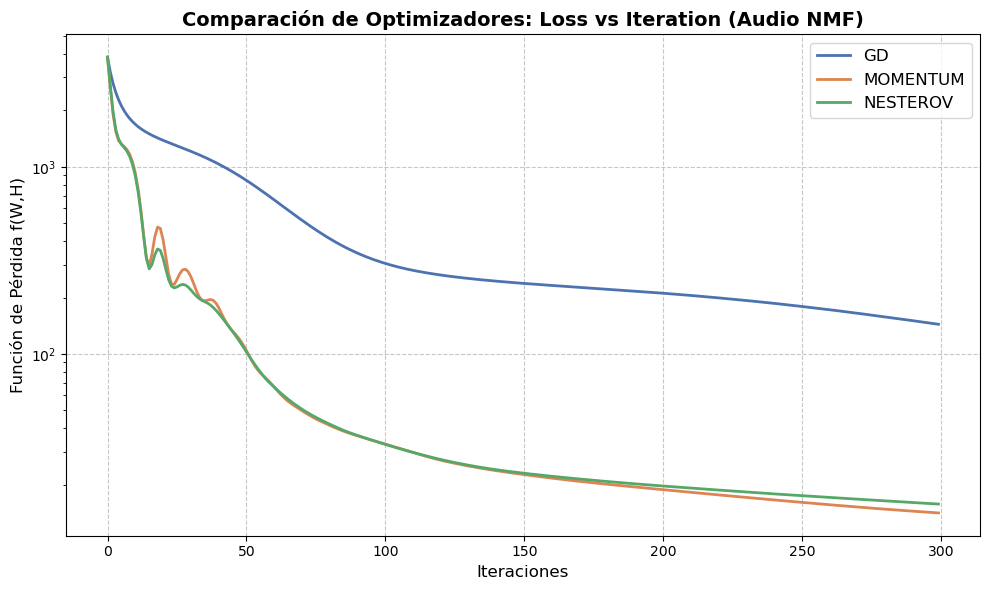

In [5]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Asumimos que la función unified_bcgd() ya está cargada en memoria.

# 1. Parámetros exactos que definiste en tu EDA
N_FFT = 1024
HOP_LENGTH = 512
SR_TARGET = 22050

# 2. Ruta a uno de tus audios reales (CAMBIA ESTO POR UN ARCHIVO REAL)
ruta_audio = r"C:\Users\frank\OneDrive\Documentos\Ibero Semestres\6tosemestre\Python\data\musan\music\fma\music-fma-0000.wav"


# 3. Cargar el audio (5 segundos para pruebas rápidas)
print("Cargando audio...")
y, sr = librosa.load(ruta_audio, sr=SR_TARGET, mono=True, duration=5.0)

# 4. Calcular el STFT y 5. Extraer la magnitud (¡ESTA ES TU MATRIZ X!)
S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
X_real = np.abs(S)

print(f"Dimensiones de la matriz X real: {X_real.shape} (Frecuencias x Tiempo)")
print(f"Valor mínimo: {X_real.min():.4f} | Valor máximo: {X_real.max():.4f}\n")

# 2. Parámetros por defecto para el Proyecto C (Audio NMF)
k_model = 10
steps = 300
alpha = 1e-3
beta = 0.9

# Diccionario para guardar los historiales
history = {}
methods = ['gd', 'momentum', 'nesterov']
colors = {'gd': '#4C72B0', 'momentum': '#DD8452', 'nesterov': '#55A868'}

# 3. Bucle de evaluación
print("Iniciando comparación de optimizadores...")
for method in methods:
    print(f"-> Entrenando con {method.upper()}...")
    
    # TRUCO VITAL: Fijar la semilla ANTES de cada ejecución.
    np.random.seed(123)
    
    # AQUÍ ESTABA EL BUG: Cambiamos X_test por X_real
    W_out, H_out, loss_hist = unified_bcgd(
        X=X_real, k=k_model, steps=steps, 
        innerW=1, innerH=1, 
        alpha_W=alpha, alpha_H=alpha, 
        method=method, beta=beta, 
        is_nmf=True, lmbda=0.0
    )
    history[method] = loss_hist

# 4. Graficar (Requisito 8.1 y 10.2)
plt.figure(figsize=(10, 6))
for method in methods:
    plt.plot(history[method], label=method.upper(), color=colors[method], linewidth=2)

plt.title('Comparación de Optimizadores: Loss vs Iteration (Audio NMF)', fontsize=14, fontweight='bold')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Función de Pérdida f(W,H)', fontsize=12)
plt.yscale('log') # La escala logarítmica permite ver mejor la convergencia asintótica
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()